基于opencv的手眼标定，眼在手上
关键关系：（tool2base的相对位姿变化）AX=XB（camera2board的相对位姿变化）

In [21]:
import os
import cv2
import cv2.aruco as aruco
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.transform import Rotation as R
from PIL import Image
import shutil
from pathlib import Path

from src.terminalplugtask.terminalplugtask.engine import HTM,read_robot_poses

# 标定板定义

## 打印标定板

在[calib.io网站](https://calib.io/pages/camera-calibration-pattern-generator)中设置并保存PDF标定板

CheckerSize与squarelength对应

MarkerSize与markerlength对应

## 检查参数并预览

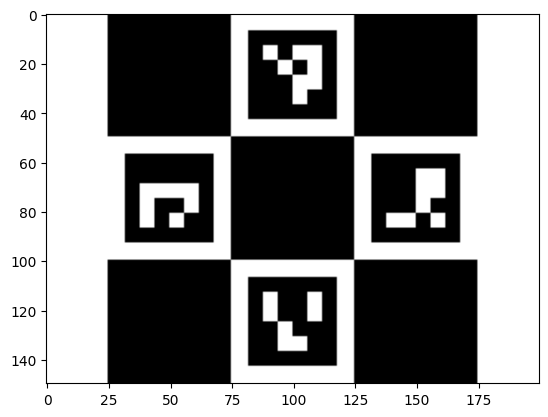

In [22]:
import cv2
from matplotlib import pyplot as plt
# w,h=7,5  #标定板内角点个数
w,h=3,3  #标定板内角点个数
# squarelength,markerlength = 35,26 #方格尺寸，aruco标记尺寸 单位mm
# squarelength,markerlength = 7,5 #方格尺寸，aruco标记尺寸 单位mm
squarelength,markerlength = 14,10 #方格尺寸，aruco标记尺寸 单位mm
# 检查边距条件
n = 4  # DICT_4X4_250有4×4个模块
module_size = markerlength / n
# To avoid deviations, the margin between chessboard square and aruco marker should be greater than 70% of one marker module.
required_margin = 0.7 * module_size
actual_margin = (squarelength - markerlength) / 2

# print(f"方格尺寸: {squarelength:.4f}mm")
# print(f"标记尺寸: {markerlength:.4f}mm") 
# print(f"模块尺寸: {module_size:.4f}mm")
# print(f"需要边距: {required_margin:.4f}mm")
# print(f"实际边距: {actual_margin:.4f}mm")

# assert actual_margin >= required_margin, f"边距不足！需要{required_margin:.6f}mm，实际{actual_margin:.6f}mm"

squarelength /= 1000
markerlength /= 1000

board = cv2.aruco.CharucoBoard(
    size=(w, h),
    squareLength=squarelength, # 方格尺寸 单位m
    markerLength=markerlength, # aruco标记尺寸 单位m
    dictionary=cv2.aruco.getPredefinedDictionary( cv2.aruco.DICT_4X4_250)
)

img=board.generateImage((200, 150), 0.5)
plt.imshow(img, cmap='gray')

# 整理标定图片

## 重命名，转PNG

In [23]:
# 源文件夹和目标文件夹
src_dir = Path("/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2")
dst_dir = src_dir / "renamed_pngs"

# 创建目标目录（如果不存在）
dst_dir.mkdir(parents=True, exist_ok=True)

# 获取所有bmp文件，按修改时间排序
bmp_files =list(src_dir.rglob("*.bmp"))
bmp_files.sort(key=lambda x: x.name)
print(bmp_files)
# 转换并保存为PNG
for idx, bmp_path in enumerate(bmp_files, 1):
    new_name = f"image_{idx:02d}.png"   
    save_path = os.path.join(dst_dir, new_name)
    
    shutil.copy(bmp_path, save_path)  
    
    print(f"Renamed: {os.path.basename(bmp_path)} -> {new_name}")

print(" Rename complete!")

[PosixPath('/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/Image_20251106105221776.bmp'), PosixPath('/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/Image_20251106105255622.bmp'), PosixPath('/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/Image_20251106105315394.bmp'), PosixPath('/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/Image_20251106105331644.bmp'), PosixPath('/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/Image_20251106105348037.bmp'), PosixPath('/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/Image_20251106105419567.bmp'), PosixPath('/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/Image_20251106105435932.bmp'), PosixPath('/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/Image_20251106105455475.bmp'), PosixPath('/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/Image_20251106105511490.bmp'), PosixPath('/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/Image_20251106105527466.bmp'), PosixPath

## 检测Charuco角点 $^{cam}_{board}T_n$

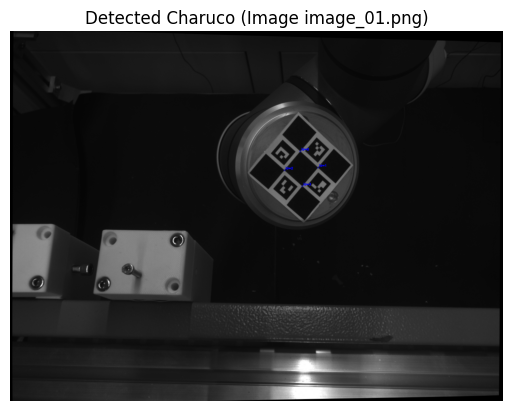

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_01.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[ 0.72863 -0.64451 -0.23173]
 [ 0.62461  0.76411 -0.16122]
 [ 0.28098 -0.02727  0.95933]]
Translation Vector: [ 0.00185 -0.05576  0.26182]


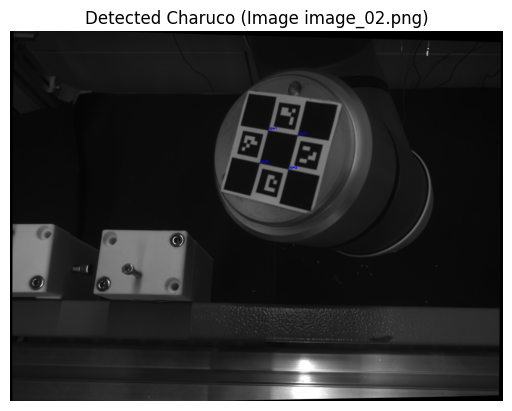

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_02.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[ 0.25723  0.85612  0.44822]
 [-0.96635  0.22697  0.12105]
 [ 0.0019  -0.46427  0.88569]]
Translation Vector: [-0.03009 -0.0112   0.19975]


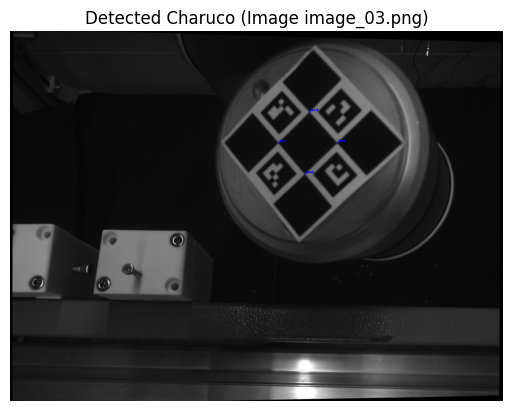

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_03.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.60541  0.71007  0.35957]
 [-0.74393 -0.66542  0.0615 ]
 [ 0.28293 -0.23026  0.93109]]
Translation Vector: [0.00167 0.00664 0.14713]


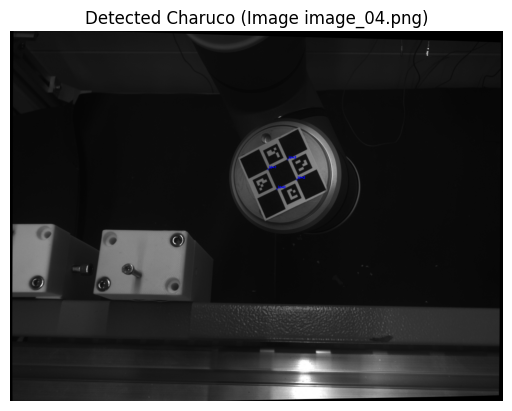

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_04.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.4062   0.88806  0.21528]
 [-0.90738 -0.41984  0.0198 ]
 [ 0.10796 -0.1873   0.97635]]
Translation Vector: [-0.01816  0.00175  0.29753]


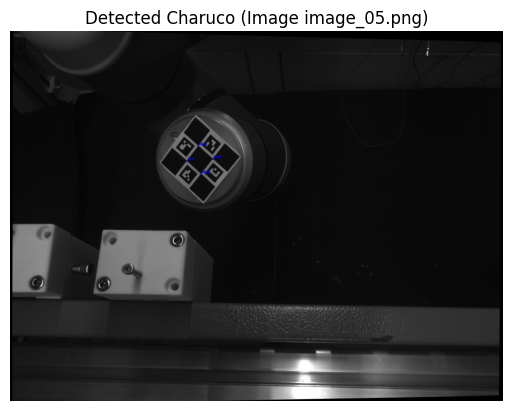

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_05.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.74306  0.63874  0.19968]
 [-0.66599 -0.73508 -0.12693]
 [ 0.06571 -0.2273   0.9716 ]]
Translation Vector: [-0.06551 -0.01027  0.33704]


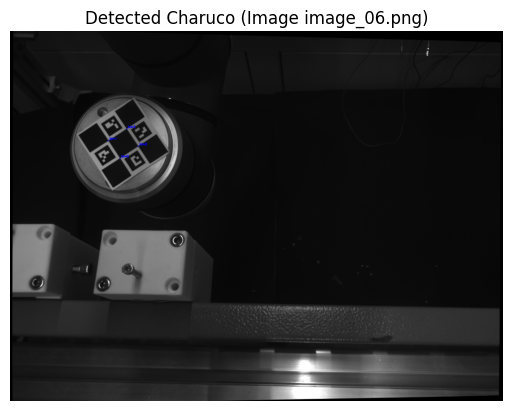

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_06.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.56533  0.82485 -0.00585]
 [-0.82149 -0.56236  0.09434]
 [ 0.07452  0.05814  0.99552]]
Translation Vector: [-0.11701 -0.01786  0.30243]


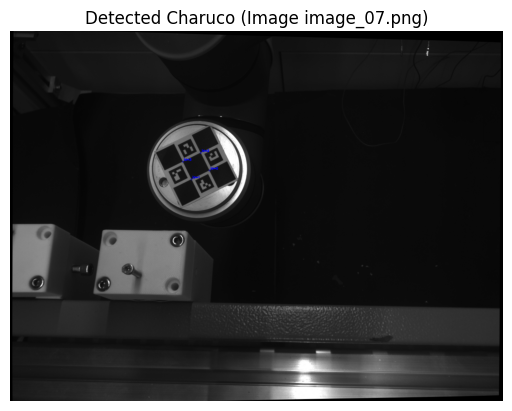

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_07.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.89343 -0.44919  0.00407]
 [ 0.44865 -0.89185  0.05754]
 [-0.02222  0.05323  0.99834]]
Translation Vector: [-0.04141 -0.02565  0.32967]


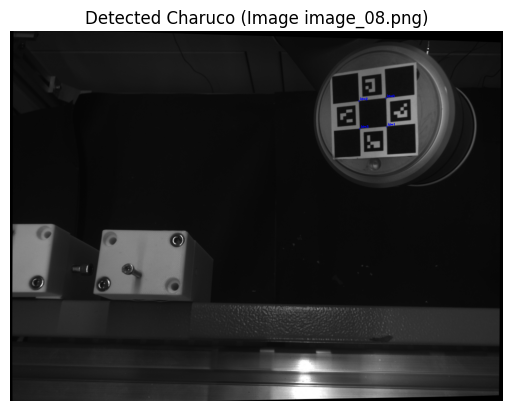

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_08.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[ 0.04619 -0.90803  0.41634]
 [ 0.99502  0.00498 -0.09952]
 [ 0.08829  0.41887  0.90374]]
Translation Vector: [ 0.05753 -0.07273  0.22738]


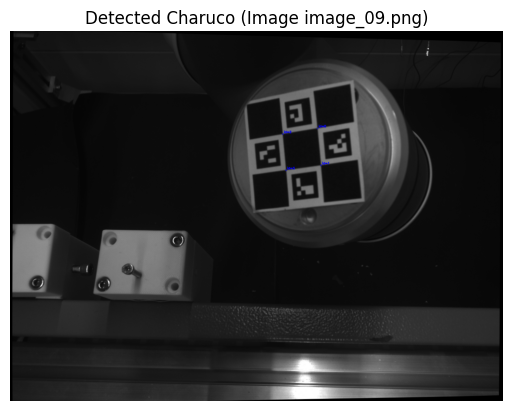

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_09.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[ 0.09305 -0.9407   0.32623]
 [ 0.99515  0.09838 -0.00016]
 [-0.03194  0.32466  0.94529]]
Translation Vector: [ 0.02032 -0.04812  0.17214]


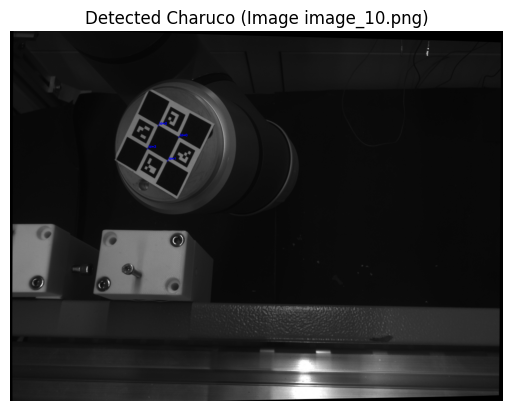

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_10.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.46739 -0.84453  0.26137]
 [ 0.87242 -0.48843 -0.01811]
 [ 0.14296  0.21956  0.96507]]
Translation Vector: [-0.04332 -0.04712  0.24438]


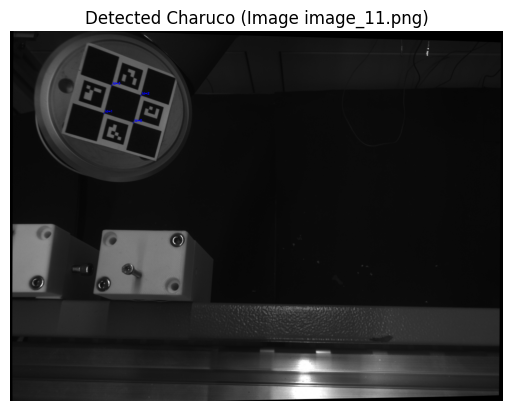

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_11.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.86183  0.2628  -0.43381]
 [-0.23241 -0.96484 -0.12279]
 [-0.45082 -0.005    0.8926 ]]
Translation Vector: [-0.07188 -0.0295   0.23974]


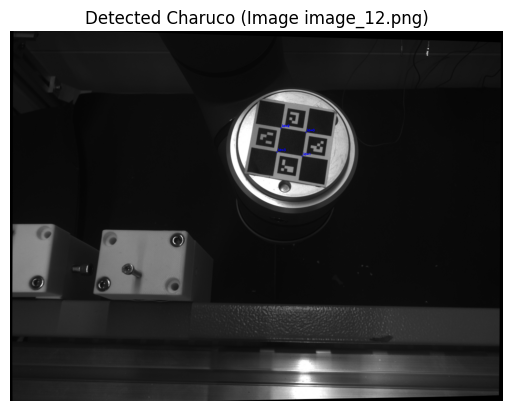

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_12.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.14972 -0.98622 -0.07045]
 [ 0.96808 -0.1607   0.19235]
 [-0.20102 -0.03941  0.97879]]
Translation Vector: [ 0.02204 -0.05736  0.26235]


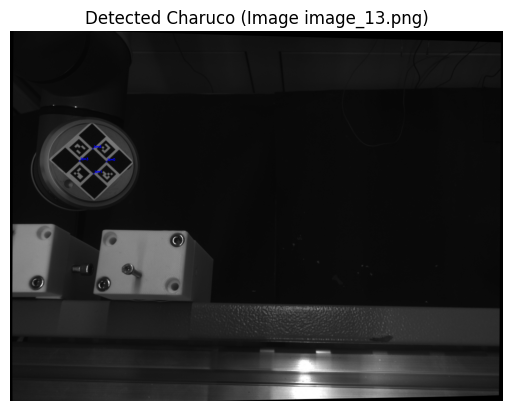

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_13.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.59511 -0.60632 -0.52747]
 [ 0.72912 -0.68338 -0.0371 ]
 [-0.33797 -0.40666  0.84876]]
Translation Vector: [-0.13489 -0.04413  0.38818]


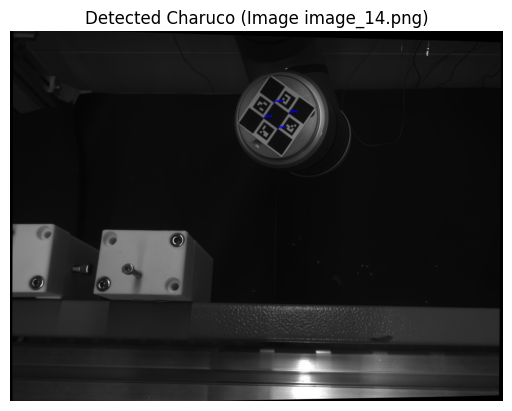

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_14.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.57712 -0.77832  0.24731]
 [ 0.79669 -0.60313 -0.03898]
 [ 0.17949  0.17453  0.96815]]
Translation Vector: [ 0.01429 -0.07874  0.3438 ]


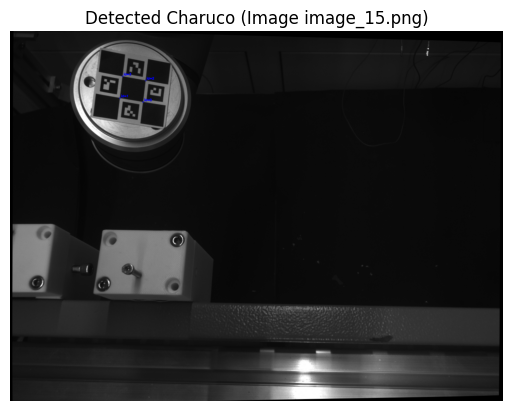

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_15.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.95709  0.09733 -0.27297]
 [-0.11042 -0.99334  0.03297]
 [-0.26794  0.06169  0.96146]]
Translation Vector: [-0.08505 -0.05721  0.3028 ]


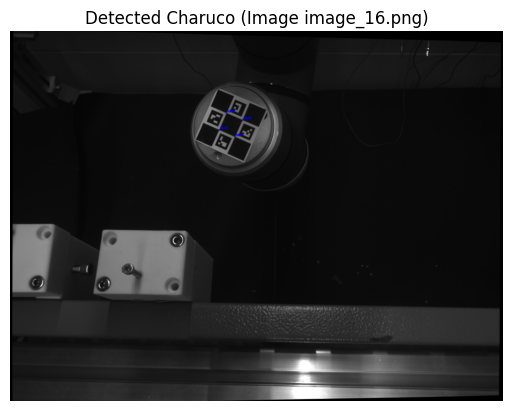

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_16.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.41191 -0.89315  0.1806 ]
 [ 0.90994 -0.41368  0.02957]
 [ 0.0483   0.17652  0.98311]]
Translation Vector: [-0.02171 -0.07981  0.35465]


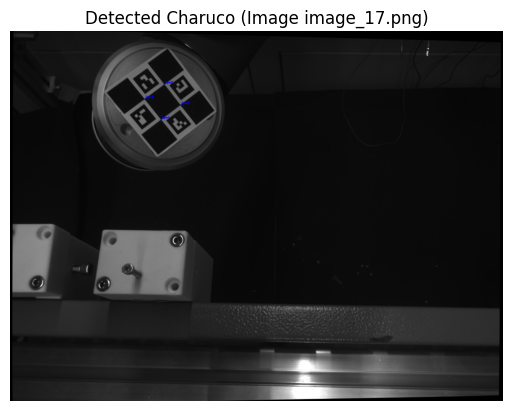

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_17.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.7333  -0.56504 -0.37815]
 [ 0.64602 -0.75244 -0.12843]
 [-0.21196 -0.33847  0.91679]]
Translation Vector: [-0.04785 -0.06223  0.27819]


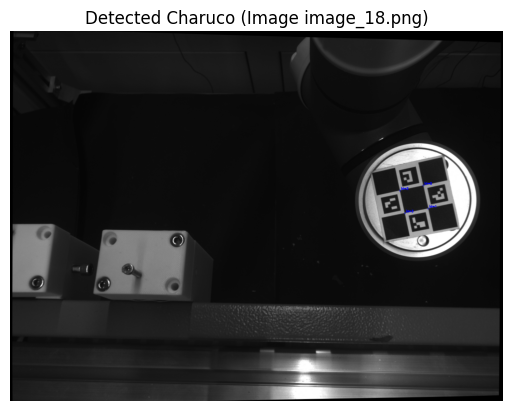

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_18.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[ 0.19198 -0.96156  0.19634]
 [ 0.97863  0.20259  0.03526]
 [-0.07368  0.18538  0.9799 ]]
Translation Vector: [ 0.0877  -0.03462  0.27983]


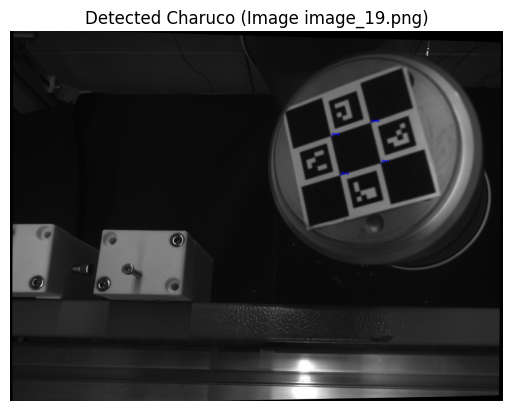

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_19.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[ 0.20458 -0.90508  0.3728 ]
 [ 0.96232  0.25567  0.09261]
 [-0.17913  0.3398   0.92328]]
Translation Vector: [ 0.03461 -0.04748  0.15148]


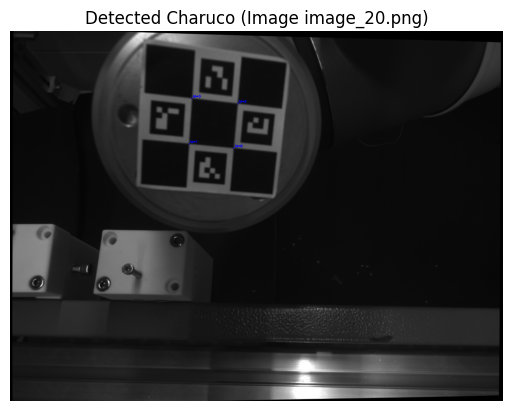

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_20.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[-0.97368  0.12218 -0.19241]
 [-0.06404 -0.95683 -0.2835 ]
 [-0.21874 -0.26371  0.93947]]
Translation Vector: [-0.00769 -0.00739  0.15732]


In [24]:
# ======== 相机内参（来自 SDK） ========
from src.terminalplugtask.terminalplugtask.engine import get_board2cam_htm_from_pic


camera_matrix = np.array([
    [ 2285.044998812351, 0.0, 1387.2791963058212],
    [0.0, 2285.044998812351, 898.1872846752417],
    [0.0, 0.0, 1.0]
])

dist_coeffs = np.zeros((5, 1))  # 因为 d 全为 0


# ======== 创建 Charuco 棋盘 ========
# charuco_board = cv2.aruco.CharucoBoard(
#     size=(7, 5),
#     squareLength=0.035,
#     markerLength=0.026,
#     dictionary=cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_250)
# )
charuco_board=board
detector = cv2.aruco.CharucoDetector(charuco_board)

# ======== 存储位姿结果 ========
R_board2cam = []
t_board2cam = []

error_ids = []

all_corners = []
rvecs = []
tvecs = []
obj_points = []

# ======== 加载图像并提取角点 ========
image_paths = list(dst_dir.rglob("*.png"))
image_paths.sort(key=lambda x: x.name)
for idx, img_path in enumerate(image_paths):
    htm_board2cam=get_board2cam_htm_from_pic(img_path,charuco_board,visualize=True)
    if htm_board2cam:
        R_board2cam.append(htm_board2cam.R)
        t_board2cam.append(htm_board2cam.P)
        rvecs.append(htm_board2cam.rvec)
        tvecs.append(htm_board2cam.tvec)
    else:
        error_ids.append(idx)
    
    # # 检测角点
    # corners, ids, _, _ = detector.detectBoard(img)
    # if corners is None or len(corners) < 4:
    #     print(f"[{idx}] {path} ❌ 棋盘角点不足，跳过")
    #     error_ids.append(idx)
    #     continue
    


    # # 匹配角点
    # obj_pts, img_pts = charuco_board.matchImagePoints(corners, ids)

    # # PnP求解位姿
    # success, rvec, tvec = cv2.solvePnP(obj_pts, img_pts, camera_matrix, dist_coeffs)
    # if not success:
    #     print(f"[{idx}] {path} ❌ solvePnP失败")
    #     error_ids.append(idx)
    #     continue
    
    # rvecs.append(rvec)
    # tvecs.append(tvec)
    # all_corners.append(corners)
    # obj_points.append(obj_pts)

    # rot_matrix, _ = cv2.Rodrigues(rvec)
    # R_board2cam.append(rot_matrix)
    # t_board2cam.append(tvec.reshape(-1))

    # # 可视化角点
    # vis_img = cv2.aruco.drawDetectedCornersCharuco(img.copy(), corners, ids)
    # plt.imshow(cv2.cvtColor(vis_img, cv2.COLOR_BGR2RGB))
    # plt.title(f"Detected Charuco (Image {idx+1})")
    # plt.axis("off")
    # plt.show()

    # print(f"[{idx}] {path} ✅ 棋盘位姿提取成功")
    # print("Rotation Matrix:\n", rot_matrix)
    # print("Translation Vector:", tvec.ravel())


# 计算标定结果

## 获取机械臂位姿 $^{base}_{grip}T_n$


In [25]:
# def read_robot_poses(file_path):
#     poses = [] 
#     with open(file_path, 'r') as f:
#         lines = f.readlines()  
#         for line in lines:
#             try:
#                 data = list(map(float, line.split(',')))
#                 if len(data) == 6:
#                     x, y, z = data[0:3]
#                     roll, pitch, yaw = data[3:6]
#                     rotation = R.from_euler('xyz', [roll, pitch, yaw])  
#                     R_matrix = rotation.as_matrix()
#                     t_vec = np.array([x, y, z])
#                     T = np.eye(4) 
#                     T[:3, :3] = R_matrix
#                     T[:3, 3] = t_vec  
#                     poses.append(T) 
#                 else:
#                     print(f"Invalid data in line: {line}")
#                     continue
#             except Exception as e:
#                 print(f"Error processing line: {line}. Error: {e}")
#                 continue
#     return poses

## 数据清洗

In [26]:
# 提取机器人位姿参数
robot_poses = read_robot_poses(src_dir/'poses_l.txt')

if error_ids:
    print("去除错误图像对应的位姿数据")
    print(f"错误图像索引: {error_ids}")
    robot_poses = [pose for idx, pose in enumerate(robot_poses) if idx not in error_ids]
    image_paths = [path for idx, path in enumerate(image_paths) if idx not in error_ids]

R_gripper2base = [pose.R for pose in robot_poses]
t_gripper2base = [pose.P for pose in robot_poses]

R_base2gripper=[pose.inv.R for pose in robot_poses]
t_base2gripper = [pose.inv.P for pose in robot_poses]

if not len(R_gripper2base) == len(R_board2cam):
    print(f"❌ 图像数与机器人位姿数不匹配: 图像数={len(R_board2cam)}, 机器人位姿数={len(R_gripper2base)}")


## 手在眼上标定 （eye in hand）

相机与夹爪的位置待标定

$$  X = ^{grip}_{cam}T  $$

移动机械臂末端，使用相机拍摄不同机械臂姿态下的标定板图片n张 (10~20)

每次采集图片和机械臂位姿，标定板和基座的位置不变

$$ 
\begin{aligned}
^{base}_{board}T &= ^{base}_{grip}T_1 \cdot ^{grip}_{cam}T \cdot ^{cam}_{board}T_1 \\
&= ^{base}_{grip}T_2 \cdot ^{grip}_{cam}T \cdot ^{cam}_{board}T_2 
\end{aligned}
$$

化简

$$ ^{base}_{grip}T_1 \cdot X \cdot ^{cam}_{board}T_1 = ^{base}_{grip}T_2 \cdot X \cdot ^{cam}_{board}T_2 $$

$$ ^{base}_{grip}T_2^{-1} \cdot ^{base}_{grip}T_1 \cdot X  =  X \cdot ^{cam}_{board}T_2 \cdot ^{cam}_{board}T_1^{-1} $$

$$ A \cdot X  =  X \cdot B $$

### 标定

In [ ]:
# ======== 手眼标定（求解 cam → gripper） ========
def compose_transform(RR, t):
    T = np.eye(4)
    T[:3, :3] = RR
    T[:3, 3] = t.ravel()  # 修复广播错误
    return T

results = []

methods = [
    cv2.CALIB_HAND_EYE_TSAI,
    cv2.CALIB_HAND_EYE_PARK,
    cv2.CALIB_HAND_EYE_HORAUD,
    cv2.CALIB_HAND_EYE_DANIILIDIS
]

# ...之前的代码保持不变（读取数据、手眼标定部分）...

print("\n===== 🤖 手眼标定结果 =====")

# 仅设置禁用科学计数法
np.set_printoptions(suppress=True)

for method in methods:
    R_cam2gripper, t_cam2gripper = cv2.calibrateHandEye(
        R_gripper2base, t_gripper2base,
        R_board2cam, t_board2cam,
        method=method
    )
    results.append((R_cam2gripper, t_cam2gripper))
    # 构造齐次变换矩阵
    T = compose_transform(R_cam2gripper, t_cam2gripper)
    
    print("cam_T_gripper:\n", T)
    
    # 保存为文本文件（逗号分隔）
    save_filename = dst_dir.parent / f"cam_T_gripper_{method}"
    np.save(save_filename, T)
    
    print(f"已保存: {save_filename}")

# 恢复默认打印选项
np.set_printoptions(suppress=False)

# 比较差异
for i in range(len(results)):
    for j in range(i + 1, len(results)):
        R1, t1 = results[i]
        R2, t2 = results[j]
        print(f"Diff between method {methods[i]} and {methods[j]}:")
        print("Rotation diff (deg):", np.rad2deg(np.arccos((np.trace(R1.T @ R2) - 1) / 2)))
        print("Translation diff (mm):", np.linalg.norm(t1 - t2) * 1000)

### AX=XB简单验证

In [ ]:
Tg1 = HTM(R=R_gripper2base[0], P=t_gripper2base[0])
Tg2 = HTM(R=R_gripper2base[1], P=t_gripper2base[1])
Tt1 = HTM(R=R_board2cam[0], P=t_board2cam[0])
Tt2 = HTM(R=R_board2cam[1], P=t_board2cam[1])

B = Tt2 @ np.linalg.inv(Tt1)
A = np.linalg.inv(Tg2) @ Tg1

# AX = XB 验证
left = A @ X
right = X @ B

print("AX:\n", left)
print("XB:\n", right)
print("Difference (AX - XB):\n", left - right)

## 标定结果验证
根据待验证的 $ X = ^{grip}_{cam}T $ 、相机读出的 $ ^{cam}_{board}T $ 以及机械臂读出的 $ ^{base}_{grip}T $

$$  ^{base}_{board}T = ^{base}_{grip}T \cdot ^{grip}_{cam}T \cdot ^{cam}_{board}T  $$
求出 $ ^{base}_{board}T $ ，应该是一个常量

In [ ]:
from robot import get_board2cam_htm_from_pic
import numpy as np
from pathlib import Path
img_files =list(src_dir.rglob("*.png"))
img_files.sort(key=lambda x: x.name)

tmp=[]

for i,img in enumerate(img_files):
    htm_board2cam=get_board2cam_htm_from_pic(img,charuco_board)
    if htm_board2cam is None:
        print(f"图像 {img} 未能检测到棋盘，跳过误差计算。")
        continue
    X=HTM(np.load(src_dir/"cam_T_gripper_4.npy"))
    # htm_board2base=X @ htm_board2cam
    htm_grip2base=robot_poses[i]
    htm_board2base=htm_grip2base @ X @ htm_board2cam
    np.set_printoptions(precision=5,suppress=True)
    tmp.append(htm_board2base)
    print(f"反推board2base标定板到夹爪结果：\n{htm_board2base}")

max_translation = max(np.linalg.norm(tmp[i].P - tmp[j].P) for i in range(len(tmp)) for j in range(i + 1, len(tmp)))
max_x_translation = max(abs(tmp[i].P[0] - tmp[j].P[0]) for i in range(len(tmp)) for j in range(i + 1, len(tmp)))
max_y_translation = max(abs(tmp[i].P[1] - tmp[j].P[1]) for i in range(len(tmp)) for j in range(i + 1, len(tmp)))
max_z_translation = max(abs(tmp[i].P[2] - tmp[j].P[2]) for i in range(len(tmp)) for j in range(i + 1, len(tmp)))

max_degree = max(
    np.rad2deg(np.arccos((np.trace(tmp[i].R.T @ tmp[j].R) - 1) / 2))
    for i in range(len(tmp)) for j in range(i + 1, len(tmp))
)
avg_translation = np.mean([np.linalg.norm(tmp[i].P - tmp[j].P) for i in range(len(tmp)) for j in range(i + 1, len(tmp))])
avg_degree = np.mean([np.rad2deg(np.arccos((np.trace(tmp[i].R.T @ tmp[j].R) - 1) / 2)) for i in range(len(tmp)) for j in range(i + 1, len(tmp))])

print(f"最大旋转误差 (deg): {max_degree:.6f}")
print(f"最大平移误差 (mm): {max_translation * 1000:.6f}")
print(f"最大X轴平移误差 (mm): {max_x_translation * 1000:.6f}")
print(f"最大Y轴平移误差 (mm): {max_y_translation * 1000:.6f}")
print(f"最大Z轴平移误差 (mm): {max_z_translation * 1000:.6f}")
print(f"平均旋转误差 (deg): {avg_degree:.6f}")
print(f"平均平移误差 (mm): {avg_translation * 1000:.6f}")

## 手在眼外标定（eye to hand）

相机与基座的位置待标定

$$  X = ^{base}_{cam}T  $$

移动机械臂末端，使用相机拍摄不同机械臂姿态下的标定板图片n张 (10~20)

每次采集图片和机械臂位姿，标定板和基夹爪的相对位置不变，变换矩阵$ ^{grip}_{board}T $

$$ 
\begin{aligned}
^{grip}_{board}T &= ^{grip}_{base}T_1 \cdot ^{base}_{cam}T \cdot ^{cam}_{board}T_1 \\
&= ^{grip}_{base}T_2 \cdot ^{base}_{cam}T \cdot ^{cam}_{board}T_2 
\end{aligned}
$$

化简

$$ ^{grip}_{base}T_1 \cdot X \cdot ^{cam}_{board}T_1 = ^{grip}_{base}T_2 \cdot X \cdot ^{cam}_{board}T_2 $$

$$ ^{grip}_{base}T_2^{-1} \cdot ^{grip}_{base}T_1 \cdot X  =  X \cdot ^{cam}_{board}T_2 \cdot ^{cam}_{board}T_1^{-1} $$

$$ A \cdot X  =  X \cdot B $$

### 标定
四种方式标定误差应该在1mm之内
后续使用第一个方法的标定结果

In [27]:
# ======== 手眼标定（求解 cam → base） ========
methods = [
    cv2.CALIB_HAND_EYE_TSAI,
    cv2.CALIB_HAND_EYE_PARK,
    cv2.CALIB_HAND_EYE_HORAUD,
    cv2.CALIB_HAND_EYE_DANIILIDIS
]

results = []

# ...之前的代码保持不变（读取数据、手眼标定部分）...

print("\n===== 🤖 手眼标定结果 =====")

# 仅设置禁用科学计数法
np.set_printoptions(suppress=True)

for method in methods:
    R_cam2base, t_cam2base = cv2.calibrateHandEye(
        R_base2gripper, t_base2gripper,
        R_board2cam, t_board2cam,
        method=method
    )

    results.append((R_cam2base, t_cam2base))
    
    # 构造齐次变换矩阵
    T = HTM(R=R_cam2base, P=t_cam2base).matrix
    
    print("cam_T_base:\n", T)
    
    # 保存为文本文件（逗号分隔）
    save_filename = dst_dir.parent / f"cam_T_base_{method}"
    np.save(save_filename, T)
    # np.savetxt(save_filename,T)
    
    print(f"已保存: {save_filename}")

# 恢复默认打印选项
np.set_printoptions(suppress=False)

# 比较差异
for i in range(len(results)):
    for j in range(i + 1, len(results)):
        R1, t1 = results[i]
        R2, t2 = results[j]
        print(f"Diff between method {methods[i]} and {methods[j]}:")
        print("Rotation diff (deg):", np.rad2deg(np.arccos((np.trace(R1.T @ R2) - 1) / 2)))
        print("Translation diff (mm):", np.linalg.norm(t1 - t2) * 1000)


===== 🤖 手眼标定结果 =====
cam_T_base:
 [[ 0.03205  0.33282  0.94244 -0.07132]
 [ 0.02984 -0.94283  0.33194 -0.81033]
 [ 0.99904  0.01749 -0.04015  0.02259]
 [ 0.       0.       0.       1.     ]]
已保存: /mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/cam_T_base_0
cam_T_base:
 [[ 0.02604  0.33289  0.9426  -0.07061]
 [ 0.0399  -0.94252  0.33176 -0.80961]
 [ 0.99886  0.02897 -0.03783  0.02279]
 [ 0.       0.       0.       1.     ]]
已保存: /mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/cam_T_base_1
cam_T_base:
 [[ 0.02611  0.33298  0.94257 -0.0706 ]
 [ 0.04017 -0.94248  0.33183 -0.8096 ]
 [ 0.99885  0.0292  -0.03798  0.0228 ]
 [ 0.       0.       0.       1.     ]]
已保存: /mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/cam_T_base_2
cam_T_base:
 [[ 0.02683  0.33277  0.94262 -0.07266]
 [ 0.03748 -0.94264  0.33171 -0.81063]
 [ 0.99894  0.02643 -0.03777  0.0225 ]
 [ 0.       0.       0.       1.     ]]
已保存: /mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/cam_T_base_

### AX=XB简单验证

In [ ]:
valimg1,valimg2=5,4
Tg1 = HTM(R=R_base2gripper[valimg1], P=t_base2gripper[valimg1])
Tg2 = HTM(R=R_base2gripper[valimg2], P=t_base2gripper[valimg2])
Tt1 = HTM(R=R_board2cam[valimg1], P=t_board2cam[valimg1])
Tt2 = HTM(R=R_board2cam[valimg2], P=t_board2cam[valimg2])

B = Tt2.matrix @ np.linalg.inv(Tt1.matrix)
A = np.linalg.inv(Tg2.matrix) @ Tg1.matrix
X = HTM(R=results[0][0],P=results[0][1]).matrix  # 使用第一个方法的结果作为 X

# AX = XB 验证
left = A @ X
right = X @ B

print("AX:\n", left)
print("XB:\n", right)
print("Difference (AX - XB):\n", left - right)

## 标定结果验证
根据待验证的 $ X = ^{base}_{cam}T $ 、相机读出的 $ ^{cam}_{board}T $ 以及机械臂读出的 $ ^{base}_{grip}T $

$$  ^{grip}_{board}T = ^{grip}_{base}T \cdot ^{base}_{cam}T \cdot ^{cam}_{board}T  $$
求出 $ ^{grip}_{board}T $ ，应该是一个常量

In [28]:
from src.terminalplugtask.terminalplugtask.engine import get_board2cam_htm_from_pic
import numpy as np
from pathlib import Path
img_files =list(src_dir.rglob("*.png"))
img_files.sort(key=lambda x: x.name)

tmp=[]

for i,img in enumerate(img_files):
    htm_board2cam=get_board2cam_htm_from_pic(img,charuco_board)
    if htm_board2cam is None:
        print(f"图像 {img} 未能检测到棋盘，跳过误差计算。")
        continue
    X=HTM(np.load(src_dir/"cam_T_base_1.npy"))
    # htm_board2base=X @ htm_board2cam
    htm_base2grip=robot_poses[i].inv
    htm_board2base=htm_base2grip @ X @ htm_board2cam
    np.set_printoptions(precision=5,suppress=True)
    tmp.append(htm_board2base)
    print(f"反推board2grip标定板到夹爪结果：\n{htm_board2base}")

max_translation = max(np.linalg.norm(tmp[i].P - tmp[j].P) for i in range(len(tmp)) for j in range(i + 1, len(tmp)))
max_x_translation = max(abs(tmp[i].P[0] - tmp[j].P[0]) for i in range(len(tmp)) for j in range(i + 1, len(tmp)))
max_y_translation = max(abs(tmp[i].P[1] - tmp[j].P[1]) for i in range(len(tmp)) for j in range(i + 1, len(tmp)))
max_z_translation = max(abs(tmp[i].P[2] - tmp[j].P[2]) for i in range(len(tmp)) for j in range(i + 1, len(tmp)))

max_degree = max(
    np.rad2deg(np.arccos((np.trace(tmp[i].R.T @ tmp[j].R) - 1) / 2))
    for i in range(len(tmp)) for j in range(i + 1, len(tmp))
)
avg_translation = np.mean([np.linalg.norm(tmp[i].P - tmp[j].P) for i in range(len(tmp)) for j in range(i + 1, len(tmp))])
avg_degree = np.mean([np.rad2deg(np.arccos((np.trace(tmp[i].R.T @ tmp[j].R) - 1) / 2)) for i in range(len(tmp)) for j in range(i + 1, len(tmp))])

print(f"最大旋转误差 (deg): {max_degree:.6f}")
print(f"最大平移误差 (mm): {max_translation * 1000:.6f}")
print(f"最大X轴平移误差 (mm): {max_x_translation * 1000:.6f}")
print(f"最大Y轴平移误差 (mm): {max_y_translation * 1000:.6f}")
print(f"最大Z轴平移误差 (mm): {max_z_translation * 1000:.6f}")
print(f"平均旋转误差 (deg): {avg_degree:.6f}")
print(f"平均平移误差 (mm): {avg_translation * 1000:.6f}")
    # print(f"反推矩阵：{htm_board2base}")
    # print(f"实际矩阵：{robot_poses[i-1]}")
    # print(f"反推位姿：{htm_board2base.pose}")
    # print(f"实际位姿：{robot_poses[i-1].pose}")
    # print(f"误差：{htm_board2base.pose-robot_poses[i-1].pose}")

/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_01.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[ 0.72863 -0.64451 -0.23173]
 [ 0.62461  0.76411 -0.16122]
 [ 0.28098 -0.02727  0.95933]]
Translation Vector: [ 0.00185 -0.05576  0.26182]
反推board2grip标定板到夹爪结果：
array([[ 0.04579, -0.99893,  0.00663,  0.01912],
       [-0.99891, -0.04584, -0.00843,  0.02175],
       [ 0.00872, -0.00623, -0.99994, -0.28649],
       [ 0.     ,  0.     ,  0.     ,  1.     ]])
/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/renamed_pngs/image_02.png ✅ 棋盘位姿提取成功
Rotation Matrix:
 [[ 0.25723  0.85612  0.44822]
 [-0.96635  0.22697  0.12105]
 [ 0.0019  -0.46427  0.88569]]
Translation Vector: [-0.03009 -0.0112   0.19975]
反推board2grip标定板到夹爪结果：
array([[ 0.04434, -0.99896, -0.01044,  0.01923],
       [-0.99902, -0.04433, -0.00115,  0.02198],
       [ 0.00069,  0.01048, -0.99994, -0.28605],
       [ 0.     ,  0.     ,  0.     ,  1.     ]])
/mnt/jzs/code/datasets/calib/global_lefthand_20251106_v2/r

## 重新映射

In [ ]:
sample_indices = np.random.choice(len(all_corners), 3, replace=False)
for idx in sample_indices:
    img = cv2.imread(image_paths[idx])
    
    # 计算重投影点
    reproj_points, _ = cv2.projectPoints(
        obj_points[idx],
        rvecs[idx],
        tvecs[idx],
        camera_matrix,
        dist_coeffs
    )
    
    # 绘制原始检测点（红色）
    for pt in all_corners[idx][0]:
        x, y = pt.astype(int)
        cv2.circle(img, (x, y), 6, (0, 0, 255), -1)
    
    # 绘制重投影点（绿色）
    for pt in reproj_points.astype(int):
        x, y = pt[0]
        cv2.circle(img, (x, y), 4, (0, 255, 0), 2)
    
    # 显示对比
    vis_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.title(f"Reprojection Check: Image {idx}")
    plt.imshow(vis_img)
    plt.axis('off')
    plt.show()


In [ ]:
#位姿多样性可视化
from mpl_toolkits.mplot3d import Axes3D

# gripper poses
gripper_positions = np.array([t for t in t_gripper2base])
# target poses
target_positions = np.array([t for t in t_target2cam])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(gripper_positions[:, 0], gripper_positions[:, 1], gripper_positions[:, 2], c='r', label='Gripper')
ax.scatter(target_positions[:, 0], target_positions[:, 1], target_positions[:, 2], c='b', label='Target')
ax.legend()
plt.title("Gripper and Target Positions")
plt.show()

In [ ]:
from scipy.spatial.transform import Rotation as R

camera_matrix = np.array(
 [[441.39519969  , 0.        , 422.12380068],
 [  0.        , 441.34518826 ,243.86423467],
 [  0.          , 0.          , 1.        ]]
 )
dist_coeffs = np.array([[-0.034186 ,   0.02101428  ,0.00291247 , 0.00085853 , 0.02932855]])


# # ========== 2. 相机到末端变换 ==========
T_cam_tool = np.array(
[[ 0.08012572 ,-0.90263992, -0.42287237,  0.05832515],
 [ 0.99671144 , 0.07769838 , 0.02300591 ,-0.01564753],
 [ 0.01209045 ,-0.4233251  , 0.90589717 , 0.20565865],
 [ 0.         , 0.        ,  0.         , 1.        ]],
)

# ========== 3. robot_pose ==========
# [x, y, z, rx, ry, rz] in RPY, 单位为米和弧度
robot_pose = [0.30516289535532576, -0.6473273493347639, 0.3967849909291525, -1.500113588201522, 0.06947818740049237, -0.2978975494025494]
position = np.array(robot_pose[:3])
rotation_rpy = robot_pose[3:]
rotation_matrix = R.from_euler('xyz', rotation_rpy).as_matrix()

T_tool2base = np.eye(4)
T_tool2base[:3, :3] = rotation_matrix
T_tool2base[:3, 3] = position

# ========== 4. uv + depth==========
u, v = 412,82
depth = 0.087


pts =np.array([[u, v]], dtype=np.float32)  
undistorted = cv2.undistortPoints(pts, camera_matrix, dist_coeffs)

x_n = undistorted[0, 0, 0]
y_n = undistorted[0, 0, 1]
print(f"去畸变后归一化坐标: [{x_n}, {y_n}]")

Xc = x_n * depth
Yc = y_n * depth
Zc = depth
print(f"相机坐标系坐标: [{Xc}, {Yc}, {Zc}]")

point_cam = np.array([Xc, Yc, Zc, 1.0])


T_camera2base = T_tool2base @ T_cam_tool
point_world = T_camera2base @ point_cam
xyz_world = point_world[:3]

print("世界坐标系坐标:", xyz_world)
